In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

cwd = os.getcwd()
root = os.path.dirname(cwd) if cwd.endswith('/code') else cwd

df = pd.read_csv(root + '/artifacts/results_grid.csv')

traj = (
    df.groupby(['model_id', 'checkpoint_idx'], as_index=False)
      .agg(
          n_params=('n_params', 'mean'),
          train_tokens_real=('train_tokens_real', 'mean'),
          val_loss=('val_loss', 'mean'),
          val_loss_std=('val_loss', 'std'),
          mu=('mu_landscape', 'mean'),
          mu_std=('mu_landscape', 'std'),
      )
)
traj['mu'] = np.clip(traj['mu'].to_numpy(), 1e-12, None)
traj['val_loss_std'] = traj['val_loss_std'].fillna(0.0)
traj['mu_std'] = traj['mu_std'].fillna(0.0)

In [2]:
all_ids = sorted(traj['model_id'].unique())

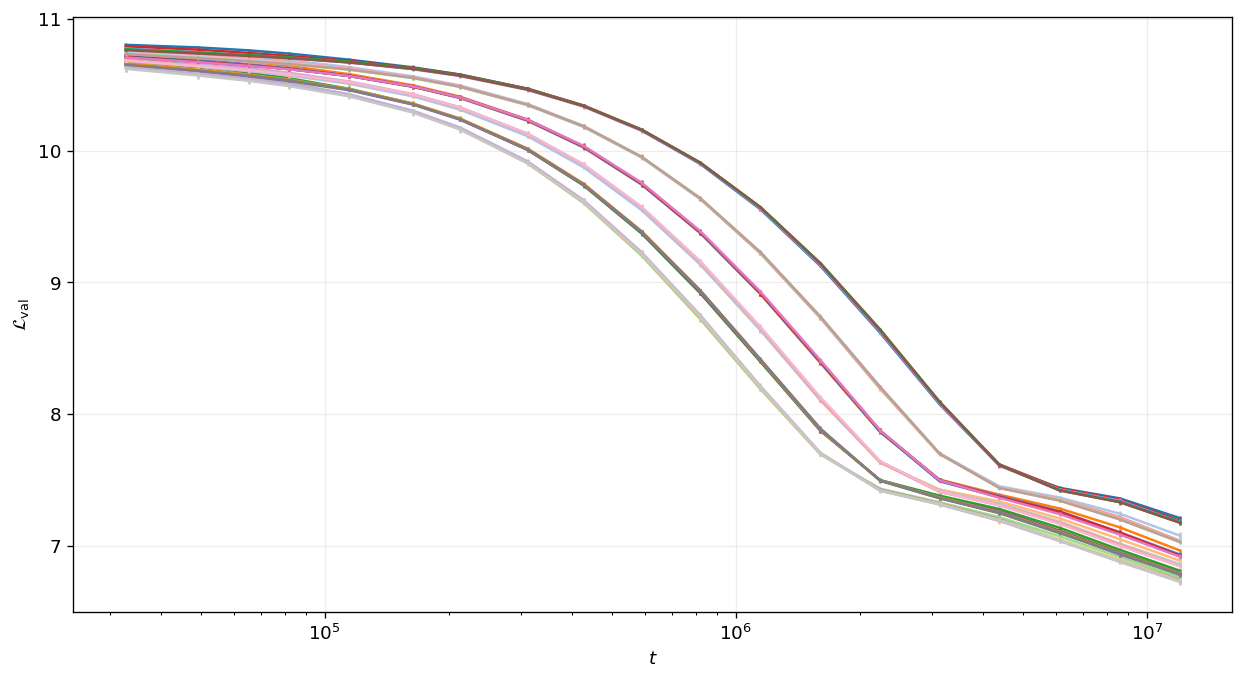

In [3]:
palette = plt.get_cmap('tab20').colors

fig, ax = plt.subplots(figsize=(10.5, 5.8))
for i, model_id in enumerate(all_ids):
    g = traj[traj['model_id'] == model_id].sort_values('train_tokens_real')
    color = palette[i % len(palette)]
    ax.plot(g['train_tokens_real'], g['val_loss'], '-', color=color)
    ax.errorbar(g['train_tokens_real'], g['val_loss'], yerr=g['val_loss_std'], fmt='none', ecolor=color)

ax.set_xscale('log')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$\mathcal{L}_{\mathrm{val}}$')
ax.grid(True, alpha=0.22)
fig.tight_layout()

out_path = root + '/paper/figures/fig_loss_all_models.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')

plt.show()

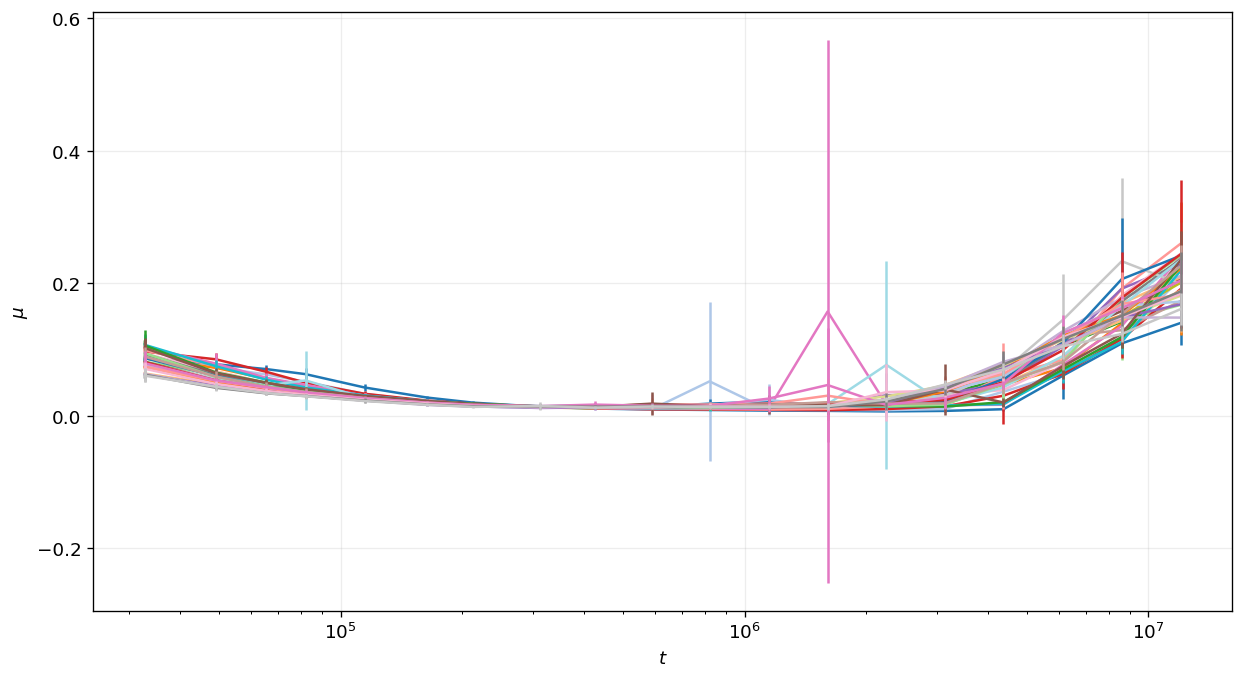

In [4]:
palette = plt.get_cmap('tab20').colors

fig, ax = plt.subplots(figsize=(10.5, 5.8))
for i, model_id in enumerate(all_ids):
    g = traj[traj['model_id'] == model_id].sort_values('train_tokens_real')
    color = palette[i % len(palette)]
    ax.plot(g['train_tokens_real'], g['mu'], '-', color=color)
    ax.errorbar(g['train_tokens_real'], g['mu'], yerr=g['mu_std'], fmt='none', ecolor=color)

ax.set_xscale('log')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$\mu$')
ax.grid(True, alpha=0.22)
fig.tight_layout()

out_path = root + '/paper/figures/fig_mu_all_models.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')

plt.show()

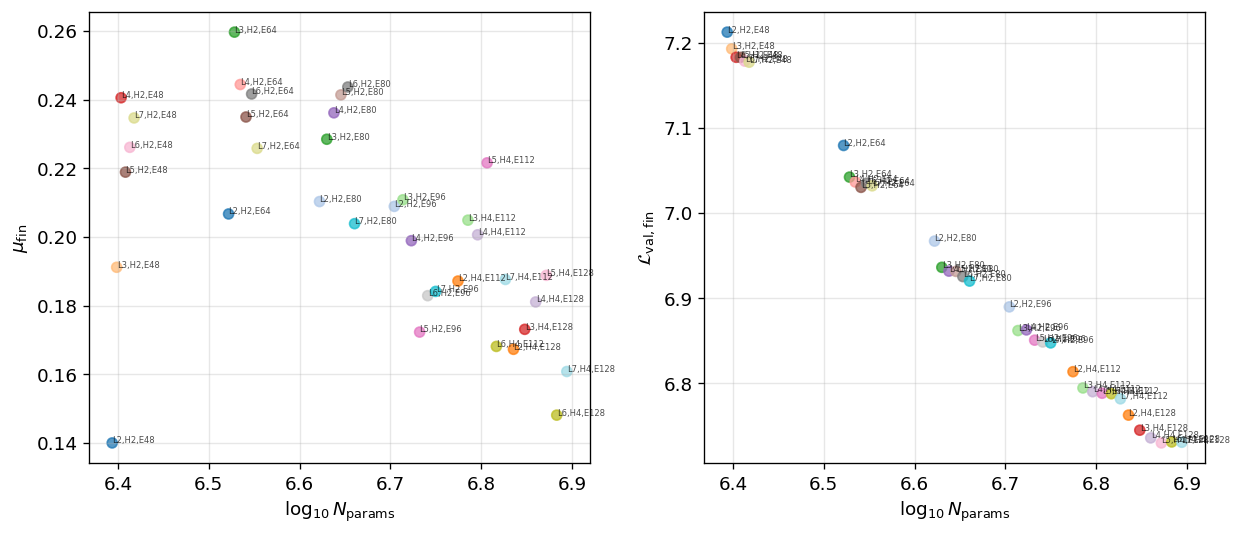

In [5]:
last = df.sort_values('checkpoint_idx').groupby(['model_id', 'seed'], as_index=False).tail(1)
agg_f = last.groupby('model_id', as_index=False).agg(
    n_params=('n_params', 'mean'),
    mu_final=('mu_landscape', 'mean'),
    val_final=('val_loss', 'mean'),
)
x = np.log10(np.maximum(agg_f['n_params'].to_numpy(), 1.0))
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6))
for ax, ycol, ylab in zip(
    axes,
    ['mu_final', 'val_final'],
    [r'$\mu_{\mathrm{fin}}$', r'$\mathcal{L}_{\mathrm{val},\mathrm{fin}}$'],
):
    y = agg_f[ycol].to_numpy(float)
    ax.scatter(x, y, s=36, alpha=0.75, c=np.arange(len(agg_f)), cmap='tab20')
    for i in range(len(agg_f)):
        short = agg_f.iloc[i]['model_id'].replace('_', ',')
        ax.annotate(short, (x[i], y[i]), fontsize=5, alpha=0.7)
    ax.set_xlabel(r'$\log_{10} N_{\mathrm{params}}$')
    ax.set_ylabel(ylab)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(root + '/paper/figures/fig_mu_arch_summary.png', dpi=220, bbox_inches='tight')
plt.show()


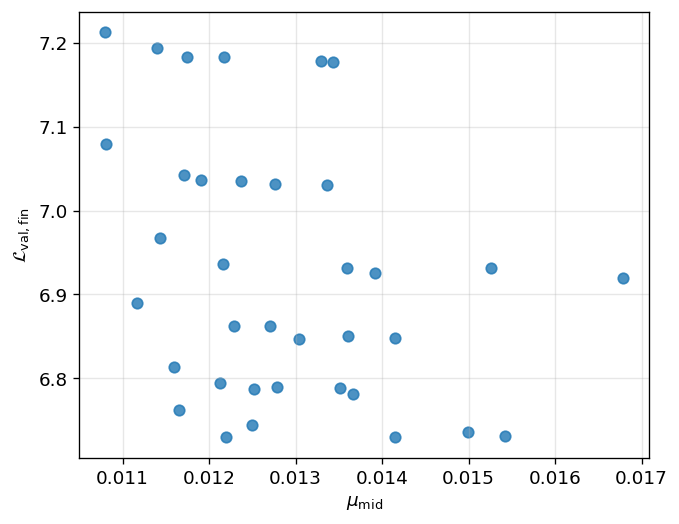

In [6]:
mid_ck = int(np.median(df['checkpoint_idx'].unique()))
g_mid = df[df['checkpoint_idx'] == mid_ck].groupby('model_id', as_index=False).agg(mu_mid=('mu_landscape', 'mean'))
g_fin = (
    df.sort_values('checkpoint_idx')
    .groupby(['model_id', 'seed'], as_index=False)
    .tail(1)
    .groupby('model_id', as_index=False)
    .agg(val_final=('val_loss', 'mean'))
)
merged = g_mid.merge(g_fin, on='model_id')
fig, ax = plt.subplots(figsize=(5.8, 4.5))
xv = merged['mu_mid'].to_numpy(float)
yv = merged['val_final'].to_numpy(float)
ax.scatter(xv, yv, s=40, alpha=0.8)
ax.set_xlabel(r'$\mu_{\mathrm{mid}}$')
ax.set_ylabel(r'$\mathcal{L}_{\mathrm{val},\mathrm{fin}}$')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(root + '/paper/figures/fig_mu_mid_vs_val_final.png', dpi=200, bbox_inches='tight')
plt.show()
